In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load Titanic dataset

titanic = sns.load_dataset("titanic")

print("Dataset Shape:", titanic.shape)
print("\nFirst 5 rows:")
print(titanic.head())

Dataset Shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# Select numerical and categorical features

data = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()

print("\nSelected Features:")
print(data.head())


Selected Features:
   pclass     sex   age  sibsp  parch     fare
0       3    male  22.0      1      0   7.2500
1       1  female  38.0      1      0  71.2833
2       3  female  26.0      0      0   7.9250
3       1  female  35.0      1      0  53.1000
4       3    male  35.0      0      0   8.0500


In [4]:
# Handle missing values

data['age'] = data['age'].fillna(data['age'].median())

# Convert categorical feature into numerical form

data['sex'] = data['sex'].map({
    'male': 0,
    'female': 1
})

print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64


In [5]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

print("Standardized Dataset Dimensions:", X_scaled.shape)

Standardized Dataset Dimensions: (891, 6)


In [6]:
# Apply PCA and reduce features to 2 dimensions

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Dataset Dimensions:", X_pca.shape)

PCA Dataset Dimensions: (891, 2)


In [7]:
# Display explained variance

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.29935785 0.28047506]

Total Explained Variance: 0.5798329148349983


In [8]:
# Create dataframe for PCA features

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("\nFirst 5 PCA Rows:")
print(pca_df.head())


First 5 PCA Rows:
        PC1       PC2
0 -0.970505 -0.835441
1  1.561132  1.277116
2 -0.474818 -0.469035
3  1.353378  1.050851
4 -1.304128  0.117142


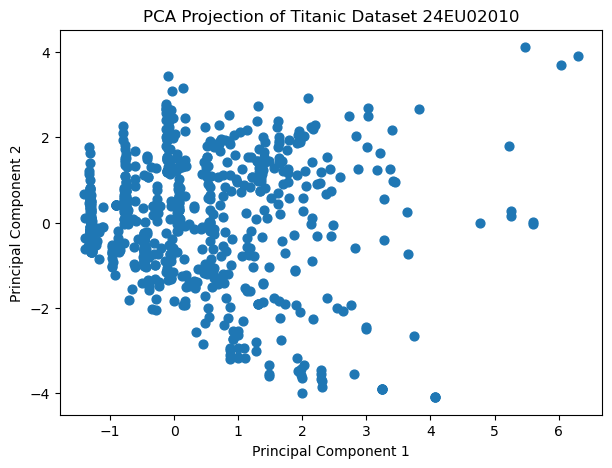

In [9]:
# Visualize transformed PCA space

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    s=40
)

plt.title("PCA Projection of Titanic Dataset 24EU02010")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [10]:
# Calculate silhouette scores for different K values

k_values = range(2, 7)
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.309257274123866
K = 3 Silhouette Score = 0.3381099690060023
K = 4 Silhouette Score = 0.3479231364353352
K = 5 Silhouette Score = 0.3716381103953102
K = 6 Silhouette Score = 0.3809226986281154


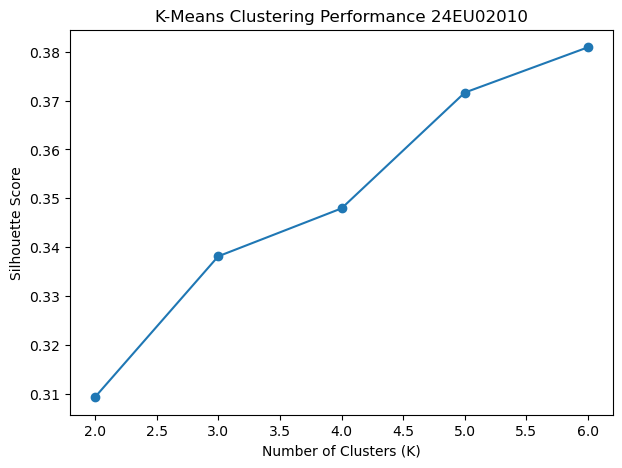

In [11]:
# Plot silhouette scores

plt.figure(figsize=(7, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering Performance 24EU02010")

plt.show()

In [12]:
# Select K with highest silhouette score

best_k = list(k_values)[np.argmax(silhouette_scores)]

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:",
      max(silhouette_scores))

Best Number of Clusters: 6
Best Silhouette Score: 0.3809226986281154


In [13]:
# K-Means on original standardized features

kmeans_original = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters_original = kmeans_original.fit_predict(X_scaled)

score_original = silhouette_score(
    X_scaled,
    clusters_original
)

print("Silhouette Score without PCA:",
      score_original)

Silhouette Score without PCA: 0.3809226986281154


In [14]:
# K-Means on PCA transformed features

kmeans_pca = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(
    X_pca,
    clusters_pca
)

print("Silhouette Score with PCA:",
      score_pca)

Silhouette Score with PCA: 0.4570012941672428


In [15]:
# Add cluster labels to PCA dataframe

pca_df['Cluster'] = clusters_pca

print(pca_df.head())

        PC1       PC2  Cluster
0 -0.970505 -0.835441        0
1  1.561132  1.277116        5
2 -0.474818 -0.469035        0
3  1.353378  1.050851        5
4 -1.304128  0.117142        0


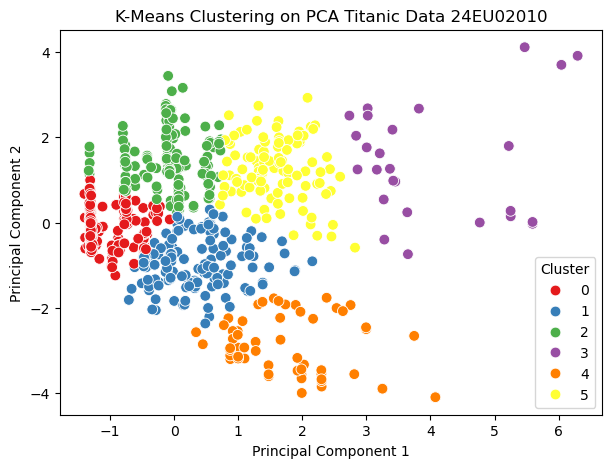

In [16]:
# Visualize clusters in PCA space

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title("K-Means Clustering on PCA Titanic Data 24EU02010")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [17]:
# Compare clustering performance

comparison = pd.DataFrame({
    'Feature Space': [
        'Original Scaled Features',
        'PCA Features'
    ],
    'Number of Features': [
        X_scaled.shape[1],
        X_pca.shape[1]
    ],
    'Silhouette Score': [
        score_original,
        score_pca
    ]
})

print(comparison)

              Feature Space  Number of Features  Silhouette Score
0  Original Scaled Features                   6          0.380923
1              PCA Features                   2          0.457001


In [18]:
print("========== FINAL RESULTS ==========")

print("\nOriginal Features:", X_scaled.shape[1])
print("PCA Features:", X_pca.shape[1])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      pca.explained_variance_ratio_.sum())

print("\nBest K:", best_k)

print("\nSilhouette Score without PCA:",
      score_original)

print("Silhouette Score with PCA:",
      score_pca)

========== FINAL RESULTS ==========

Original Features: 6
PCA Features: 2

Explained Variance Ratio:
[0.29935785 0.28047506]

Total Explained Variance: 0.5798329148349983

Best K: 6

Silhouette Score without PCA: 0.3809226986281154
Silhouette Score with PCA: 0.4570012941672428


In [19]:
# Number of passengers in each PCA cluster

print("\nCluster Distribution:")

print(
    pd.Series(clusters_pca)
    .value_counts()
    .sort_index()
)


Cluster Distribution:
0    386
1    152
2    159
3     26
4     63
5    105
Name: count, dtype: int64
